# Exploratory Data Analysis (EDA)
German Migration Analysis

Goal:
- Validate cleaned dataset
- Check plausibility
- Explore trends

## Validate cleaned dataset

In [1]:
# 01 Check venv
import sys
print(sys.executable)

/Users/andreasgilling/Documents/GitHub/german-migration-analysis/venv/bin/python


In [2]:
# 02 Conig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_style("whitegrid")

In [3]:
# 03 Load master dataset
df = pd.read_csv("../data/processed/migration_master_dataset.csv")

df.head()

,year,dimension_type,dimension_value,direction,value
0,1950,global,global,emigration,78148
1,1950,global,global,immigration,96140
2,1951,global,global,emigration,126071
3,1951,global,global,immigration,88349
4,1952,global,global,emigration,135796


In [4]:
df.shape

(10848, 5)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10848 entries, 0 to 10847
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   year             10848 non-null  int64
 1   dimension_type   10848 non-null  str  
 2   dimension_value  10848 non-null  str  
 3   direction        10848 non-null  str  
 4   value            10848 non-null  int64
dtypes: int64(2), str(3)
memory usage: 423.9 KB


In [6]:
# 04 Basic validation

# Missing values
df.isnull().sum()

year               0
dimension_type     0
dimension_value    0
direction          0
value              0
dtype: int64

In [7]:
# Check directions
df["direction"].unique()

<StringArray>
['emigration', 'immigration']
Length: 2, dtype: str

In [8]:
# Check dimension types
df["dimension_type"].unique()

<StringArray>
['global', 'country', 'age']
Length: 3, dtype: str

In [9]:
# Negative values
df[df["value"] < 0]

,year,dimension_type,dimension_value,direction,value


## Global Analysis

### Basic EDA

In [10]:
# 05 Global Dataframe
df_global = df[df["dimension_type"] == "global"].copy()

df_global.head()

,year,dimension_type,dimension_value,direction,value
0,1950,global,global,emigration,78148
1,1950,global,global,immigration,96140
2,1951,global,global,emigration,126071
3,1951,global,global,immigration,88349
4,1952,global,global,emigration,135796


In [11]:
df_global = df_global[df_global['year'] >= 2000]
df_global.head()

,year,dimension_type,dimension_value,direction,value
100,2000,global,global,emigration,674038
101,2000,global,global,immigration,841158
102,2001,global,global,emigration,606494
103,2001,global,global,immigration,879217
104,2002,global,global,emigration,623255


In [12]:
df_global.shape

(50, 5)

In [13]:
# 06 Pivot direction
pivot_global = df_global.pivot_table(
    index="year",
    columns="direction",
    values="value",
    aggfunc="sum"
).reset_index()

In [14]:
# Check - each year 2 directions
df_global.groupby("year")["direction"].nunique()

year
2000    2
2001    2
2002    2
2003    2
2004    2
2005    2
2006    2
2007    2
2008    2
2009    2
2010    2
2011    2
2012    2
2013    2
2014    2
2015    2
2016    2
2017    2
2018    2
2019    2
2020    2
2021    2
2022    2
2023    2
2024    2
Name: direction, dtype: int64

### Net Migration

In [15]:
pivot_global.head()

direction,year,emigration,immigration
0,2000,674038,841158
1,2001,606494,879217
2,2002,623255,842543
3,2003,626330,768975
4,2004,697633,780175


In [16]:
# Adding net_migration
pivot_global["net_migration"] = (
    pivot_global["immigration"] - pivot_global["emigration"]
)

In [17]:
# Adding return_rate
pivot_global["return_rate"] = (
    pivot_global["immigration"] / pivot_global["emigration"]
)
pivot_global.head()

direction,year,emigration,immigration,net_migration,return_rate
0,2000,674038,841158,167120,1.247939
1,2001,606494,879217,272723,1.449671
2,2002,623255,842543,219288,1.351843
3,2003,626330,768975,142645,1.227747
4,2004,697633,780175,82542,1.118317


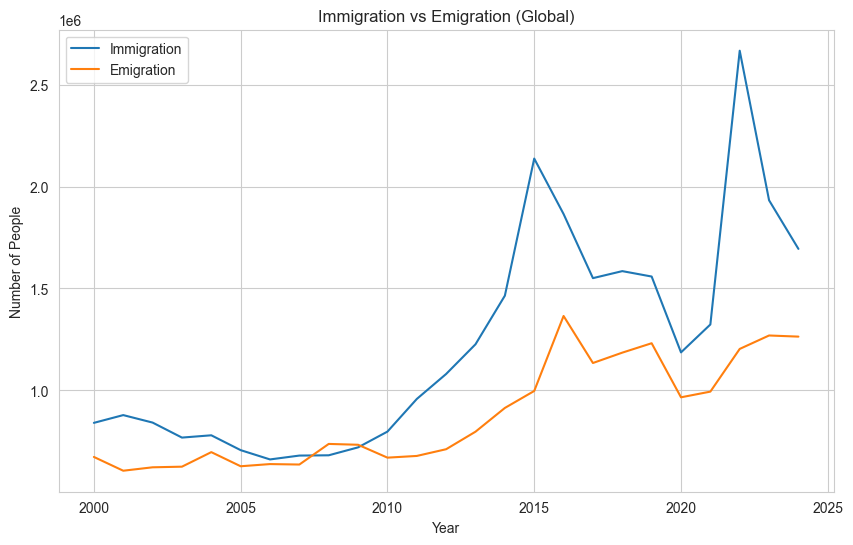

In [18]:
# Plot Global immigration and emigration
plt.figure(figsize=(10,6))
plt.plot(pivot_global["year"], pivot_global["immigration"])
plt.plot(pivot_global["year"], pivot_global["emigration"])

plt.title("Immigration vs Emigration (Global)")
plt.xlabel("Year")
plt.ylabel("Number of People")
plt.legend(["Immigration", "Emigration"])
plt.show()

### Return Rate

In [19]:
# 07 Load return rate
return_global_file = "../data/processed/return_rate_global.csv"
return_global = pd.read_csv(return_global_file)

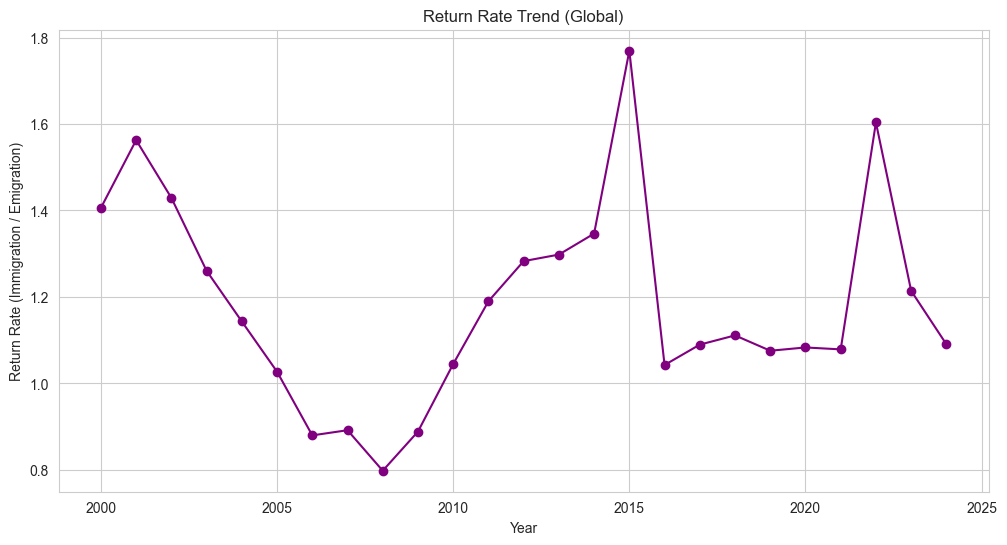

In [20]:
# Plot Global Return Rate Trend
plt.figure(figsize=(12,6))
plt.plot(return_global['year'], return_global['return_rate_global'], marker='o', color='purple')
plt.title("Return Rate Trend (Global)")
plt.xlabel("Year")
plt.ylabel("Return Rate (Immigration / Emigration)")
plt.grid(True)
plt.show()

## Global Net Migration & Return Rate

We analyze the global net migration (immigration − emigration) and the return rate (immigration / emigration) from 2000 onwards.

- Net migration indicates whether more people leave or enter Germany in a given year.
- Return rate shows the fraction of emigrants returning as immigrants in the same year.

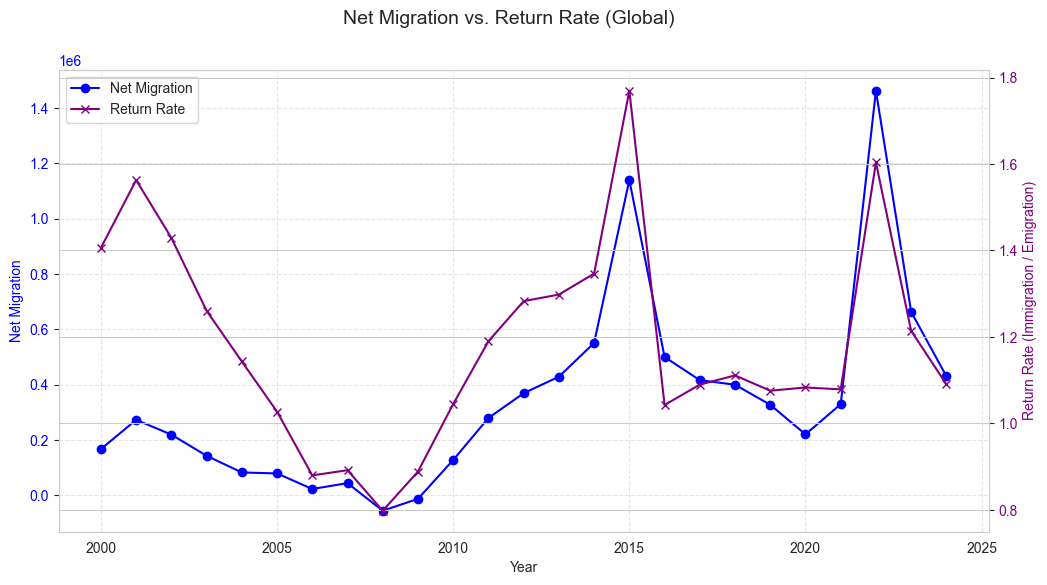

In [21]:
# Plot Global Net Migration + Return Rate
fig, ax1 = plt.subplots(figsize=(12,6))

# Net Migration plotten
ax1.plot(pivot_global['year'], pivot_global['immigration'] - pivot_global['emigration'],
         color='blue', marker='o', label='Net Migration')
ax1.set_xlabel("Year")
ax1.set_ylabel("Net Migration", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.5)

# Return Rate plotten
ax2 = ax1.twinx()
ax2.plot(return_global['year'], return_global['return_rate_global'],
         color='purple', marker='x', label='Return Rate')
ax2.set_ylabel("Return Rate (Immigration / Emigration)", color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

# Titel and Legend
fig.suptitle("Net Migration vs. Return Rate (Global)", fontsize=14)

# Combine
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.show()

In [22]:
return_global.head()

,year,emigration,immigration,return_rate_global
0,2000,1007770,1416885,1.405961
1,2001,935015,1461091,1.562639
2,2002,976304,1395149,1.429011
3,2003,1008131,1270623,1.260375
4,2004,1149634,1314154,1.143106


In [23]:
return_global.describe()

,year,emigration,immigration,return_rate_global
count,25.000000,2.500000e+01,2.500000e+01,25.000000
mean,2012.000000,1.429536e+06,1.685864e+06,1.184205
std,7.359801,4.302373e+05,5.890216e+05,0.238347
min,2000.000000,9.350150e+05,9.720190e+05,0.797945
25%,2006.000000,1.099365e+06,1.270623e+06,1.044745
50%,2012.000000,1.218732e+06,1.461091e+06,1.110970
75%,2018.000000,1.882184e+06,2.189705e+06,1.297880
max,2024.000000,2.209411e+06,3.220031e+06,1.769431


In [24]:
return_global.tail()

,year,emigration,immigration,return_rate_global
20,2020,1627165,1762334,1.083070
21,2021,1737790,1874416,1.078621
22,2022,2008184,3220031,1.603454
23,2023,2064643,2506567,1.214044
24,2024,2073967,2261513,1.090429


# Peak-Analysis

In [25]:
pivot_global[['immigration', 
                 'emigration', 
                 'net_migration', 
                 'return_rate']].describe()

direction,immigration,emigration,net_migration,return_rate
count,2.500000e+01,2.500000e+01,2.500000e+01,25.000000
mean,1.223724e+06,8.795916e+05,3.441323e+05,1.356244
std,5.391568e+05,2.564701e+05,3.447929e+05,0.303895
min,6.618550e+05,6.064940e+05,-5.574300e+04,0.924456
25%,7.801750e+05,6.706050e+05,1.276770e+05,1.190391
50%,1.080936e+06,7.378890e+05,2.793300e+05,1.337160
75%,1.558612e+06,1.134641e+06,4.286070e+05,1.449671
max,2.665772e+06,1.365178e+06,1.462089e+06,2.214679


In [26]:
## highest net migration
pivot_global.sort_values(
    'net_migration', ascending=False
).head(5)

direction,year,emigration,immigration,net_migration,return_rate
22,2022,1203683,2665772,1462089,2.214679
15,2015,997552,2136954,1139402,2.142198
23,2023,1269545,1932509,662964,1.522206
14,2014,914241,1464724,550483,1.602120
16,2016,1365178,1865122,499944,1.366212


In [27]:
## lowest net migration
pivot_global.sort_values(
    'net_migration'
).head(5)

direction,year,emigration,immigration,net_migration,return_rate
8,2008,737889,682146,-55743,0.924456
9,2009,733796,721014,-12782,0.982581
6,2006,639064,661855,22791,1.035663
7,2007,636854,680766,43912,1.068951
5,2005,628399,707352,78953,1.125642


In [28]:
## highest return rate
pivot_global.sort_values(
    'return_rate', ascending=False
).head(5)

direction,year,emigration,immigration,net_migration,return_rate
22,2022,1203683,2665772,1462089,2.214679
15,2015,997552,2136954,1139402,2.142198
14,2014,914241,1464724,550483,1.602120
13,2013,797886,1226493,428607,1.537178
23,2023,1269545,1932509,662964,1.522206


In [29]:
## lowest return rate
pivot_global.sort_values(
    'return_rate'
).head(5)

direction,year,emigration,immigration,net_migration,return_rate
8,2008,737889,682146,-55743,0.924456
9,2009,733796,721014,-12782,0.982581
6,2006,639064,661855,22791,1.035663
7,2007,636854,680766,43912,1.068951
4,2004,697633,780175,82542,1.118317


In [30]:
## highest relative change in return rate
pivot_global['return_rate_change'] = (
    pivot_global['return_rate'].pct_change()
)

pivot_global.sort_values(
    'return_rate_change', ascending=False
).head(5)

direction,year,emigration,immigration,net_migration,return_rate,return_rate_change
22,2022,1203683,2665772,1462089,2.214679,0.663860
15,2015,997552,2136954,1139402,2.142198,0.337102
10,2010,670605,798282,127677,1.190391,0.211494
11,2011,678969,958299,279330,1.411403,0.185664
1,2001,606494,879217,272723,1.449671,0.161653


### Quantitative Findings – Global Level

- Highest net migration: 2022
- Lowest net migration: 2008
- Highest return rate: 2022
- Lowest return rate: 2008
- Strongest relative increase in return rate: 2022


## Net Migration & Return Rate Analysis

This section calculates the key migration indicators used throughout the project.

Definitions:

- **Net Migration** = Immigration − Emigration  
- **Return Rate** = Emigration / Immigration  

These indicators help identify:
- migration peaks
- crisis or policy effects
- long-term migration dynamics


In [31]:

# Create pivot table for immigration / emigration
pivot_global = (
    df_global
    .pivot_table(
        index="year",
        columns="direction",
        values="value",
        aggfunc="sum"
    )
    .reset_index()
)

pivot_global = pivot_global.rename(columns={
    "Immigration": "immigration",
    "Emigration": "emigration"
})

# Calculate indicators
pivot_global["net_migration"] = pivot_global["immigration"] - pivot_global["emigration"]
pivot_global["return_rate"] = pivot_global["emigration"] / pivot_global["immigration"]

pivot_global.head()


direction,year,emigration,immigration,net_migration,return_rate
0,2000,674038,841158,167120,0.801322
1,2001,606494,879217,272723,0.689812
2,2002,623255,842543,219288,0.739731
3,2003,626330,768975,142645,0.814500
4,2004,697633,780175,82542,0.894201


In [32]:

# Key statistics

highest_net_year = pivot_global.loc[pivot_global["net_migration"].idxmax(), "year"]
lowest_net_year = pivot_global.loc[pivot_global["net_migration"].idxmin(), "year"]

highest_return_year = pivot_global.loc[pivot_global["return_rate"].idxmax(), "year"]
lowest_return_year = pivot_global.loc[pivot_global["return_rate"].idxmin(), "year"]

print("Highest net migration year:", highest_net_year)
print("Lowest net migration year:", lowest_net_year)
print("Highest return rate year:", highest_return_year)
print("Lowest return rate year:", lowest_return_year)


Highest net migration year: 2022
Lowest net migration year: 2008
Highest return rate year: 2008
Lowest return rate year: 2022



### Interpretation (to be refined later)

Initial findings typically highlight:

- Years with strong migration surges
- Years with strong return movements
- Possible structural breaks in migration patterns

These observations will later be connected with:

- EU enlargement
- refugee crises
- labor market conditions
- economic shocks
